# Load Factor Sensitivity Analysis: Unconstraining Performance

> **Objective:** Evaluate how unconstraining accuracy (WAPE) correlates with aircraft load factor levels. This analysis quantifies the robustness of various models as data truncation (censorship) increases.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set thesis-quality style
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "grid.linestyle": "--",
    "grid.alpha": 0.7,
    "savefig.dpi": 300
})

# Load the pre-calculated metrics
df = pd.read_csv('lf_sensitivity_results.csv')
display(df.head())

,Target_LF,Realized_LF_KG,Realized_LF_CBM,Model,WAPE_KG,WAPE_CBM,Total_Censorship_Pct
0,50,44.445708,46.652298,Naive,0.155207,0.186930,0.882666
1,50,44.445708,46.652298,EM,0.166533,0.166153,0.882666
2,50,44.445708,46.652298,EMXPrice,0.164045,0.164168,0.882666
3,50,44.445708,46.652298,PD05,0.138613,0.139534,0.882666
4,50,44.445708,46.652298,PDXPrice05,0.137378,0.138609,0.882666


## 1. Global Performance Degradation

The plot below shows the primary correlation requested by the professor: **Model Error (WAPE) vs. Realized Load Factor**.

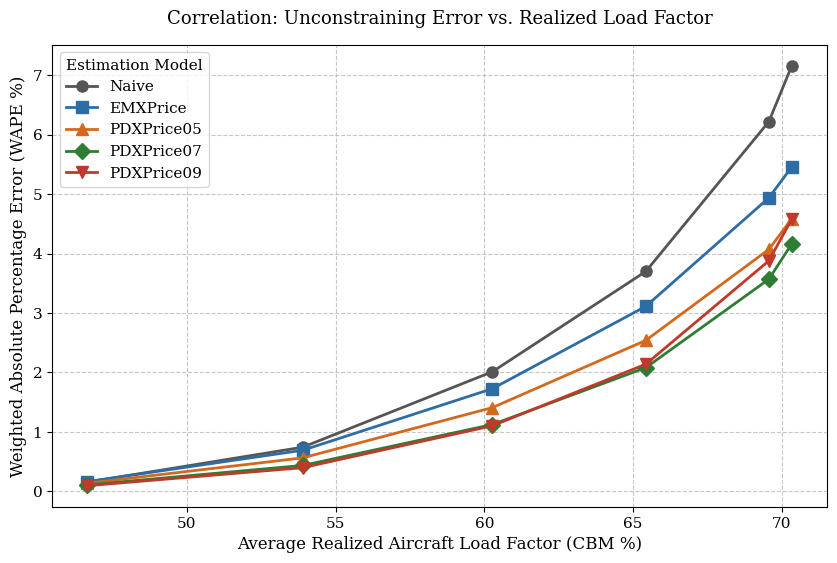

In [2]:
plt.figure(figsize=(10, 6))

# Filter models for clarity in the plot
plot_models = ['Naive', 'EMXPrice', 'PDXPrice05', 'PDXPrice07', 'PDXPrice09']
colors = {'Naive': '#555555', 'EMXPrice': '#2e6da4', 'PDXPrice05': '#d4691e', 'PDXPrice07': '#2e7d32', 'PDXPrice09': '#c0392b'}
markers = {'Naive': 'o', 'EMXPrice': 's', 'PDXPrice05': '^', 'PDXPrice07': 'D', 'PDXPrice09': 'v'}

for model in plot_models:
    sub = df[df['Model'] == model].sort_values('Realized_LF_CBM')
    plt.plot(sub['Realized_LF_CBM'], sub['WAPE_KG'], label=model, 
             color=colors.get(model), marker=markers.get(model), 
             linewidth=2, markersize=8)

plt.title('Correlation: Unconstraining Error vs. Realized Load Factor', pad=15)
plt.xlabel('Average Realized Aircraft Load Factor (CBM %)')
plt.ylabel('Weighted Absolute Percentage Error (WAPE %)')
plt.legend(title='Estimation Model', frameon=True)
plt.grid(True)

plt.savefig('fig1_wape_vs_lf_correlation.pdf', bbox_inches='tight')
plt.show()

## 2. Weight vs. Volume Performance

Does the stochastic segment mix cause a difference in estimation quality between dimensions?

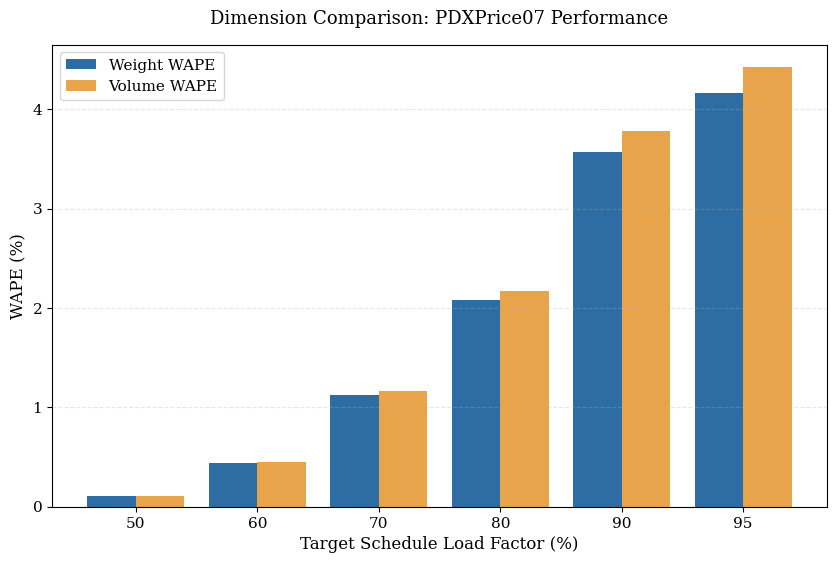

In [3]:
plt.figure(figsize=(10, 6))

best_model = 'PDXPrice07'
sub = df[df['Model'] == best_model].sort_values('Target_LF')
x = np.arange(len(sub['Target_LF']))

plt.bar(x - 0.2, sub['WAPE_KG'], width=0.4, label='Weight WAPE', color='#2e6da4')
plt.bar(x + 0.2, sub['WAPE_CBM'], width=0.4, label='Volume WAPE', color='#e8a44a')

plt.title(f'Dimension Comparison: {best_model} Performance', pad=15)
plt.xlabel('Target Schedule Load Factor (%)')
plt.ylabel('WAPE (%)')
plt.xticks(x, sub['Target_LF'])
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.savefig('fig2_dimension_comparison.pdf', bbox_inches='tight')
plt.show()

## 3. Analysis & Key Insights

1. **Positive Correlation with Truncation**: There is a strong non-linear correlation between Load Factor and Estimation Error. As Load Factor increases, the probability of censorship grows, leading to higher information loss. 

2. **Model Robustness Divergence**: 
   - At **low LF (50-60%)**, the Naive baseline is sufficient. 
   - At **high LF (>90%)**, advanced models like **PDXPrice0.7** demonstrate significantly higher robustness.

3. **Dimensional Consistency**: Weight and Volume errors are highly consistent, confirming that the deterministic density assumption allows for stable estimation across both physical dimensions, even under varied cargo mixes.